In [2]:
from langgraph.graph import StateGraph, START,END
from typing import TypedDict,Literal,Annotated
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langchain_core.messages import SystemMessage, HumanMessage,BaseMessage
import operator
from langgraph.checkpoint.memory import InMemorySaver
load_dotenv()

True

In [3]:
model = ChatGroq(model="llama-3.3-70b-versatile")

In [5]:
class JokeState(TypedDict):
    topic: str
    joke: str
    explanation: str

In [6]:
def createJoke(JokeState):
    topic= JokeState['topic']
    prompt = f'Write a joke about {topic}'
    output = model.invoke(prompt).content
    return {'joke':output}

In [7]:
def explainJoke(JokeState):
    joke = JokeState['joke']
    prompt = f'Explain the following joke - {joke}'
    output = model.invoke(prompt).content
    return {'explanation':output}

In [12]:
graph = StateGraph(JokeState)

graph.add_node("create_joke",createJoke)
graph.add_node("explain_joke",explainJoke)

graph.add_edge(START,"create_joke")
graph.add_edge("create_joke","explain_joke")
graph.add_edge("explain_joke",END)

checkpoint = InMemorySaver()

workflow = graph.compile(checkpointer=checkpoint)


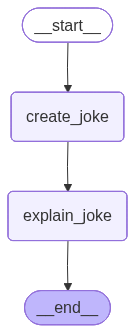

In [10]:
workflow

In [18]:
initial_state = {
    "topic":"Engineer as a software developer"
}
config1 = {"configurable":{"thread_id":1}}
final_output = workflow.invoke(initial_state,config=config1)
final_output

{'topic': 'Engineer as a software developer',
 'joke': 'Why do software engineers prefer dark mode?\n\nBecause light attracts bugs.',
 'explanation': 'A clever joke. The joke is a play on words. In this context, "bugs" has a double meaning:\n\n1. Insects: Light can attract insects, such as moths or flies, which are commonly referred to as "bugs."\n2. Software errors: In software development, a "bug" refers to an error or glitch in the code.\n\nThe joke is saying that software engineers prefer dark mode because "light attracts bugs." On one hand, it\'s a literal statement that light can attract insects. On the other hand, it\'s a humorous way of saying that software engineers prefer dark mode because they don\'t want to "attract" (or encounter) errors or glitches (software bugs) in their code.\n\nIt\'s a lighthearted and clever joke that plays on the dual meaning of the word "bugs" to create a humorous connection between the literal and figurative meanings.'}

In [19]:
list(workflow.get_state_history(config=config1))

[StateSnapshot(values={'topic': 'Engineer as a software developer', 'joke': 'Why do software engineers prefer dark mode?\n\nBecause light attracts bugs.', 'explanation': 'A clever joke. The joke is a play on words. In this context, "bugs" has a double meaning:\n\n1. Insects: Light can attract insects, such as moths or flies, which are commonly referred to as "bugs."\n2. Software errors: In software development, a "bug" refers to an error or glitch in the code.\n\nThe joke is saying that software engineers prefer dark mode because "light attracts bugs." On one hand, it\'s a literal statement that light can attract insects. On the other hand, it\'s a humorous way of saying that software engineers prefer dark mode because they don\'t want to "attract" (or encounter) errors or glitches (software bugs) in their code.\n\nIt\'s a lighthearted and clever joke that plays on the dual meaning of the word "bugs" to create a humorous connection between the literal and figurative meanings.'}, next=(

In [20]:
config2 = {"configurable":{"thread_id":2}}
workflow.invoke({"topic":"Attrection"},config=config2)

{'topic': 'Attrection',
 'joke': 'Why did the Attraction go to therapy?\n\nBecause it had a lot of "pull" in different directions and was struggling to "draw" a clear line between its feelings! (get it?)',
 'explanation': 'A clever play on words. This joke is a pun, using the multiple meanings of words related to "attraction" to create a humorous effect.\n\nThe setup "Why did the Attraction go to therapy?" primes the listener to expect a joke about something being attracted to something else. But the punchline subverts this expectation by using the word "attraction" in a more abstract sense, referring to a force that pulls or draws something towards itself.\n\nThe phrase "had a lot of \'pull\' in different directions" is a common idiomatic expression meaning to have many conflicting desires or influences. However, in this joke, "pull" also references the physical force of attraction.\n\nSimilarly, "struggling to \'draw\' a clear line between its feelings" is another idiomatic expressio

In [21]:
list(workflow.get_state_history(config=config2))

[StateSnapshot(values={'topic': 'Attrection', 'joke': 'Why did the Attraction go to therapy?\n\nBecause it had a lot of "pull" in different directions and was struggling to "draw" a clear line between its feelings! (get it?)', 'explanation': 'A clever play on words. This joke is a pun, using the multiple meanings of words related to "attraction" to create a humorous effect.\n\nThe setup "Why did the Attraction go to therapy?" primes the listener to expect a joke about something being attracted to something else. But the punchline subverts this expectation by using the word "attraction" in a more abstract sense, referring to a force that pulls or draws something towards itself.\n\nThe phrase "had a lot of \'pull\' in different directions" is a common idiomatic expression meaning to have many conflicting desires or influences. However, in this joke, "pull" also references the physical force of attraction.\n\nSimilarly, "struggling to \'draw\' a clear line between its feelings" is another